# **DECISION TREE**

In [ ]:
import pandas as pd
import numpy as np
from math import log2
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
import matplotlib.pyplot as plt

In [ ]:
data = {
    'Outlook': ['Rainy', 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Sunny',
                'Overcast', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Overcast',
                'Overcast', 'Sunny'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
             'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild',
             'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True,
              True, False, False, False, True, True,
              False, True],
    'PlayGolf': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
                 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes',
                 'Yes', 'No']
}

df = pd.DataFrame(data)
print("📊 Dataset Play Golf")
display(df)

📊 Dataset Play Golf


,Outlook,Temp,Humidity,Windy,PlayGolf
0,Rainy,Hot,High,False,No
1,Rainy,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Sunny,Mild,High,False,Yes
4,Sunny,Cool,Normal,False,Yes
5,Sunny,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Rainy,Mild,High,False,No
8,Rainy,Cool,Normal,False,Yes
9,Sunny,Mild,Normal,False,Yes


In [ ]:
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    return np.sum([(-counts[i]/np.sum(counts)) * log2(counts[i]/np.sum(counts))
                   for i in range(len(elements))])

In [ ]:
def info_gain(data, split_attribute_name, target_name="PlayGolf"):
    total_entropy = entropy(data[target_name])
    vals, counts = np.unique(data[split_attribute_name], return_counts=True)
    weighted_entropy = np.sum([
        (counts[i]/np.sum(counts)) *
        entropy(data.where(data[split_attribute_name] == vals[i])
                .dropna()[target_name])
        for i in range(len(vals))
    ])
    return total_entropy - weighted_entropy

In [ ]:
for col in df.columns[:-1]:
    print(f"Information Gain untuk {col}: {info_gain(df, col):.4f}")

Information Gain untuk Outlook: 0.3806
Information Gain untuk Temp: 0.0391
Information Gain untuk Humidity: 0.0611
Information Gain untuk Windy: 0.1281


In [ ]:
X = df[['Outlook', 'Temp', 'Humidity', 'Windy']]
y = df['PlayGolf']

# Mengubah data kategorikal ke numerik
X_encoded = pd.get_dummies(X)
print("\n🧩 Data setelah One-Hot Encoding:")
display(X_encoded)

model = DecisionTreeClassifier(criterion="entropy", random_state=0)
model.fit(X_encoded, y)


🧩 Data setelah One-Hot Encoding:


,Windy,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Temp_Cool,Temp_Hot,Temp_Mild,Humidity_High,Humidity_Normal
0,False,False,True,False,False,True,False,True,False
1,True,False,True,False,False,True,False,True,False
2,False,True,False,False,False,True,False,True,False
3,False,False,False,True,False,False,True,True,False
4,False,False,False,True,True,False,False,False,True
5,True,False,False,True,True,False,False,False,True
6,True,True,False,False,True,False,False,False,True
7,False,False,True,False,False,False,True,True,False
8,False,False,True,False,True,False,False,False,True
9,False,False,False,True,False,False,True,False,True


DecisionTreeClassifier(criterion='entropy', random_state=0)

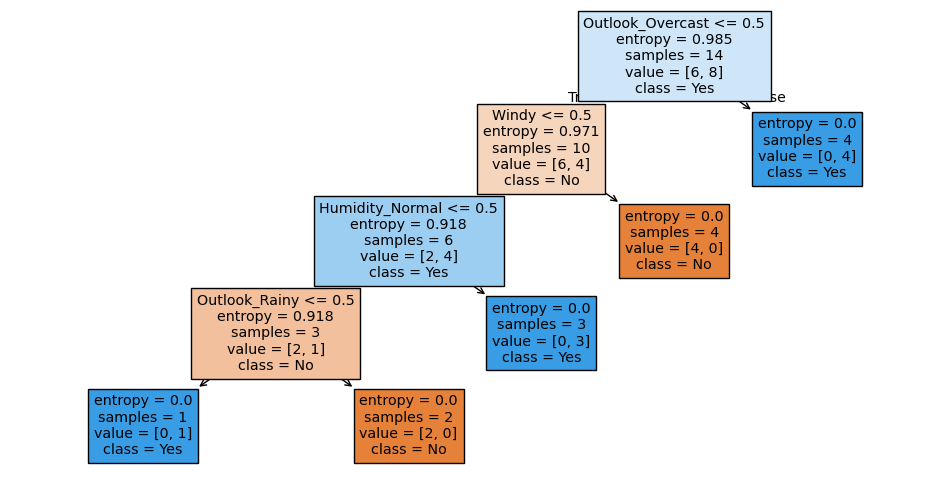

In [ ]:
plt.figure(figsize=(12, 6))
tree.plot_tree(model, filled=True, feature_names=X_encoded.columns, class_names=model.classes_)
plt.show()

In [ ]:
rules = export_text(model, feature_names=list(X_encoded.columns))
print("\n📜 Aturan Decision Tree:\n")
print(rules)


📜 Aturan Decision Tree:

|--- Outlook_Overcast <= 0.50
|   |--- Windy <= 0.50
|   |   |--- Humidity_Normal <= 0.50
|   |   |   |--- Outlook_Rainy <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- Outlook_Rainy >  0.50
|   |   |   |   |--- class: No
|   |   |--- Humidity_Normal >  0.50
|   |   |   |--- class: Yes
|   |--- Windy >  0.50
|   |   |--- class: No
|--- Outlook_Overcast >  0.50
|   |--- class: Yes



In [ ]:
sample_data = pd.DataFrame({
    'Outlook': ['Rainy'],
    'Temp': ['Cool'],
    'Humidity': ['Normal'],
    'Windy': [False]
})

# Ubah sample ke format yang sama dengan data training
sample_encoded = pd.get_dummies(sample_data)
sample_encoded = sample_encoded.reindex(columns=X_encoded.columns, fill_value=0)

print("\n🧾 Data baru setelah encoding:")
display(sample_encoded)

prediction = model.predict(sample_encoded)
print(f"\n🔮 Prediksi untuk data baru: {prediction[0]}")


🧾 Data baru setelah encoding:


,Windy,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Temp_Cool,Temp_Hot,Temp_Mild,Humidity_High,Humidity_Normal
0,False,0,True,0,True,0,0,0,True



🔮 Prediksi untuk data baru: Yes


# **Praktikum Decision Tree Kelas**

Pustaka Program Decision Tree

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Loading Dataset

In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# membaca file csv menggunakan pandas
df = pd.read_csv("/content/gdrive/MyDrive/Machine Learning/Pertemuan5/Praktikum/data/stunting_wasting_dataset.csv")
df.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Jenis Kelamin      100000 non-null  object 
 1   Umur (bulan)       100000 non-null  int64  
 2   Tinggi Badan (cm)  100000 non-null  float64
 3   Berat Badan (kg)   100000 non-null  float64
 4   Stunting           100000 non-null  object 
 5   Wasting            100000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 4.6+ MB


Data Preprocessing

In [ ]:
# Cek duplicate
df.duplicated().sum()


np.int64(7308)

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

In [ ]:
# Cek duplicate ulang setelah menghapus
df.duplicated().sum()

np.int64(0)

In [ ]:
# Mengubah nama kolom (rename columns)
df = df.rename(columns={
    'Jenis Kelamin' : 'jenis_kelamin',
    'Umur (bulan)' : 'umur_bulan',
    'Tinggi Badan' : 'tinggi_badan',
    'Berat Badan' : 'berat_badan',
    'Stunting' : 'stunting',
    'Wasting' : 'wasting'
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92692 entries, 0 to 99997
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   jenis_kelamin      92692 non-null  object 
 1   umur_bulan         92692 non-null  int64  
 2   Tinggi Badan (cm)  92692 non-null  float64
 3   Berat Badan (kg)   92692 non-null  float64
 4   stunting           92692 non-null  object 
 5   wasting            92692 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 5.0+ MB


Data Understanding (Exploratory Data Analysis)

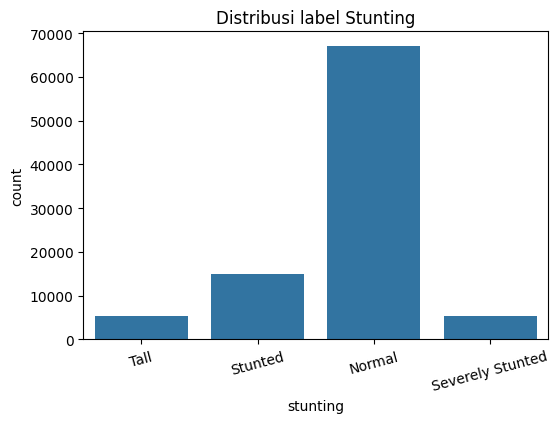

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='stunting', data=df)
plt.title('Distribusi label Stunting')
plt.xticks(rotation=15)
plt.show()

Encoding Data Kategorikal (Mapping Label ke Kode Numerik)

In [ ]:
# mapping label -> kode untuk target
stunting_cat = df['stunting'].astype('category')
stunting_classes = list(stunting_cat.cat.categories)  # urutan kelas
df['stunting'] = stunting_cat.cat.codes               # y numerik

# fitur kategorikal lain (jenis_kelamin, wasting) -> kode juga
for col in ['jenis_kelamin', 'wasting']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

df.head()

,jenis_kelamin,umur_bulan,Tinggi Badan (cm),Berat Badan (kg),stunting,wasting
0,0,19,91.6,13.3,3,1
1,0,20,77.7,8.5,2,3
2,0,10,79.0,10.3,0,1
3,1,2,50.3,8.3,1,1
4,1,5,56.4,10.9,1,1


Analisis Korelasi Antar Fitur

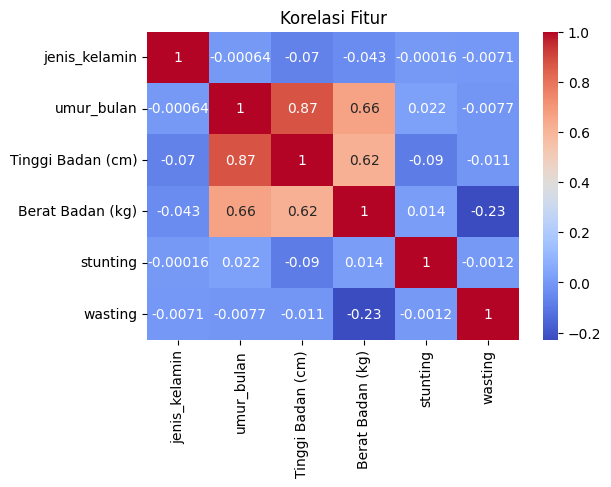

In [ ]:
# Korelasi
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

Splitting Data (Pembagian Data Training dan Testing)

In [ ]:
# Cek nama kolom yang ada di dataset
print(df.columns.tolist())

['jenis_kelamin', 'umur_bulan', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'stunting', 'wasting']


In [ ]:
df = df.rename(columns={
    'Tinggi Badan (cm)': 'tinggi_cm',
    'Berat Badan (kg)': 'berat_kg'
})

In [ ]:
# Memilih fitur dan target
feature_cols = ['umur_bulan', 'tinggi_cm', 'berat_kg', 'wasting']
X = df[feature_cols]
y = df['stunting']

# Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)

(74153, 18539)

Pembuatan Model Decision Tree

In [ ]:
# Membangun model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Evaluasi Model Decision Tree

In [ ]:
# Evaluasi
y_pred = dt.predict(X_test)

print("Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=stunting_classes
))

Akurasi: 77.67 %

Confusion Matrix:
 [[12901     0   481    29]
 [  587    25   455     0]
 [ 1653     0  1355     0]
 [  935     0     0   118]]

Classification Report:
                   precision    recall  f1-score   support

          Normal       0.80      0.96      0.88     13411
Severely Stunted       1.00      0.02      0.05      1067
         Stunted       0.59      0.45      0.51      3008
            Tall       0.80      0.11      0.20      1053

        accuracy                           0.78     18539
       macro avg       0.80      0.39      0.41     18539
    weighted avg       0.78      0.78      0.73     18539



Visualisasi Hasil Model Decision Tree

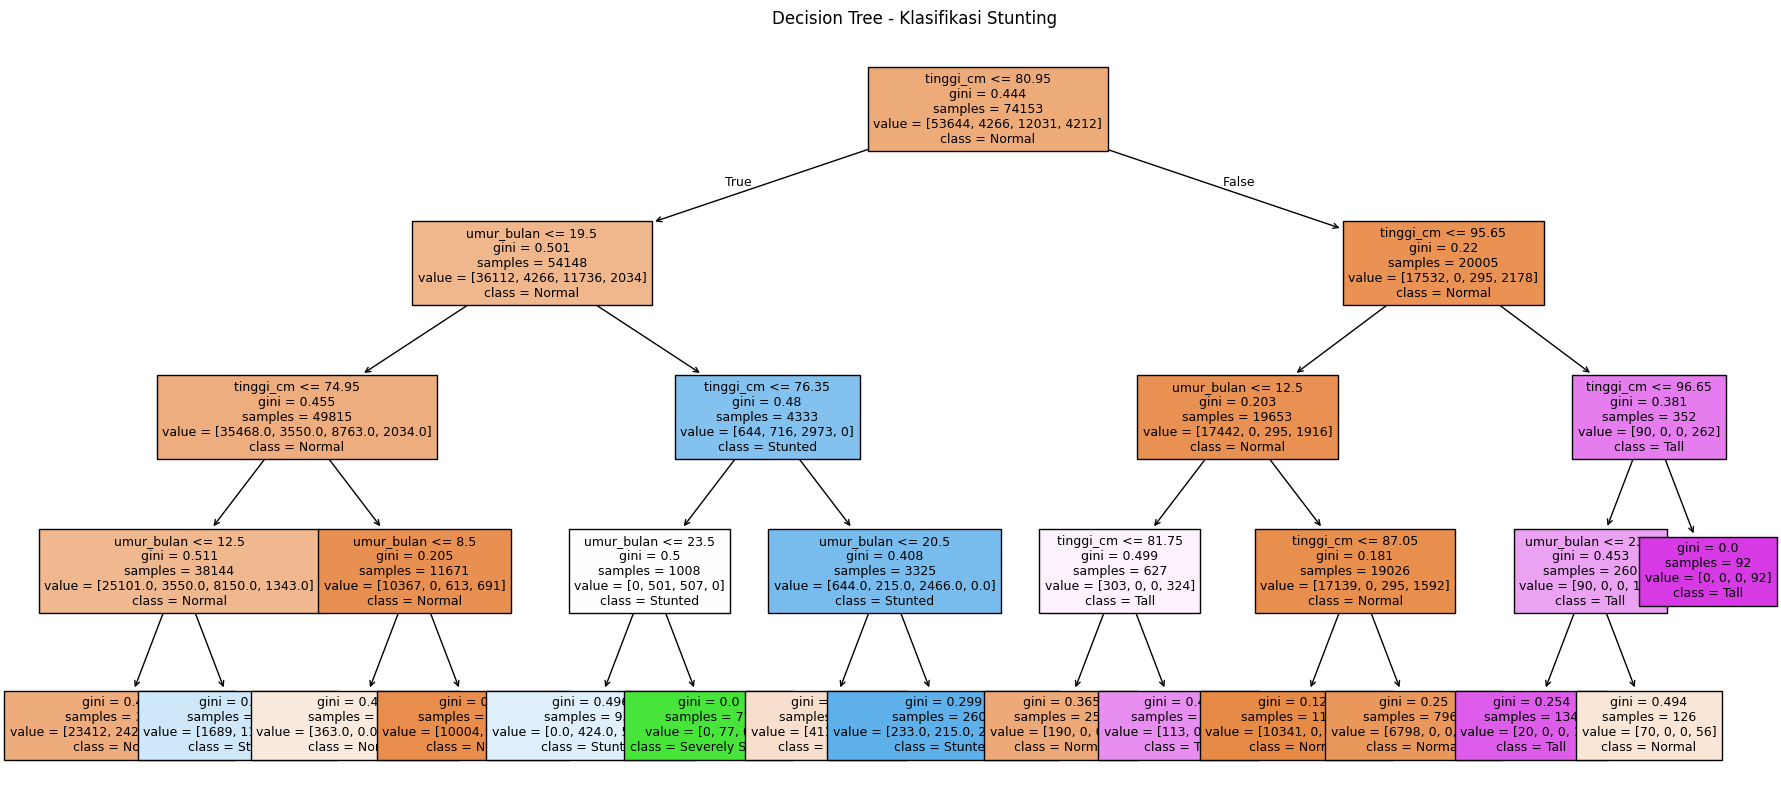

In [ ]:
# Visualisasi model
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=stunting_classes,   # kembali ke nama kelas asli
    filled=True,
    fontsize=9
)
plt.title("Decision Tree - Klasifikasi Stunting")
plt.show()

Feature Importance (Fitur yang Paling Berpengaruh)

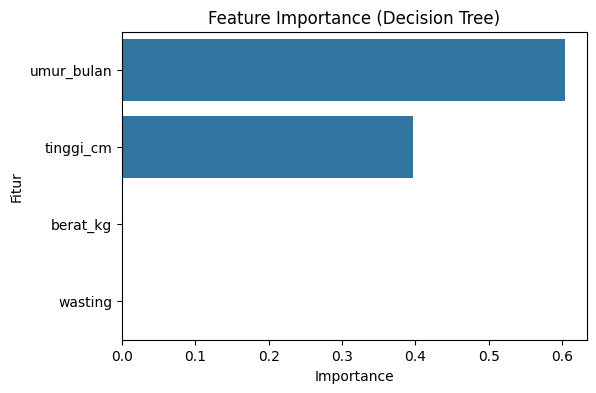

,0
umur_bulan,0.603752
tinggi_cm,0.396248
berat_kg,0.000000
wasting,0.000000


In [ ]:
# Fitur yang penting
imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=imp, y=imp.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

imp

Hyperparameter Tuning (Menentukan max_depth Terbaik)

In [ ]:
scores = {}
for d in range(2, nine := 9):
  m = DecisionTreeClassifier(max_depth=d, random_state=42)
  m.fit(X_train, y_train)
  scores[d] = accuracy_score(y_test, m.predict(X_test))

scores
best_d = max(scores, key=scores.get)
print("Best max_depth:", best_d, "| Acc:", round(scores[best_d]*100,2), "%")

Best max_depth: 8 | Acc: 84.22 %
